In [1]:
# ============================================================
#  InvoiceGuard — Complete Pipeline
#  Run this file top to bottom in VSCode as a Jupyter Notebook
#  or run: python invoiceguard_main.py
# ============================================================

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
from skimage.feature import hog
from tqdm import tqdm

print("✅ All libraries loaded!")
print(f"   TensorFlow version : {tf.__version__}")

✅ All libraries loaded!
   TensorFlow version : 2.20.0


In [3]:
# Get the folder where THIS file lives
BASE_DIR      = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.path.abspath('.')
DATA_DIR      = os.path.join(BASE_DIR, 'invoices_dataset')
PROCESSED_DIR = os.path.join(BASE_DIR, 'invoices_dataset', 'processed')
OUTPUT_DIR    = os.path.join(BASE_DIR, 'outputs')
MODEL_DIR     = os.path.join(BASE_DIR, 'models')

IMG_SIZE    = 64
RANDOM_SEED = 42
CLASSES     = ['utilities', 'travel', 'office_supplies', 'entertainment']
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

# Create folders
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,    exist_ok=True)
os.makedirs(MODEL_DIR,     exist_ok=True)

print(f"✅ Folders ready!")
print(f"   DATA_DIR      : {DATA_DIR}")
print(f"   PROCESSED_DIR : {PROCESSED_DIR}")
print(f"   OUTPUT_DIR    : {OUTPUT_DIR}")
print(f"   MODEL_DIR     : {MODEL_DIR}")
print(f"   Class mapping : {CLASS_TO_IDX}")

✅ Folders ready!
   DATA_DIR      : d:\Lecture Notes\projects\InvoiceGuard\invoices_dataset
   PROCESSED_DIR : d:\Lecture Notes\projects\InvoiceGuard\invoices_dataset\processed
   OUTPUT_DIR    : d:\Lecture Notes\projects\InvoiceGuard\outputs
   MODEL_DIR     : d:\Lecture Notes\projects\InvoiceGuard\models
   Class mapping : {'utilities': 0, 'travel': 1, 'office_supplies': 2, 'entertainment': 3}


In [4]:
def load_images(data_dir, classes, img_size):
    X, y = [], []
    for cls in classes:
        cls_folder = os.path.join(data_dir, cls)
        if not os.path.exists(cls_folder):
            print(f"  ❌ Folder not found: {cls_folder}")
            continue

        files = [f for f in os.listdir(cls_folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
        print(f"  Loading '{cls}' — {len(files)} images")

        for fname in tqdm(files, desc=cls):
            fpath = os.path.join(cls_folder, fname)
            img   = cv2.imread(fpath)
            if img is None:
                continue

            gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            resized    = cv2.resize(gray, (img_size, img_size), interpolation=cv2.INTER_AREA)
            normalized = resized.astype(np.float32) / 255.0
            flat       = normalized.flatten()

            X.append(flat)
            y.append(CLASS_TO_IDX[cls])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("\n📂 Loading images...")
X_raw, y_raw = load_images(DATA_DIR, CLASSES, IMG_SIZE)
print(f"\n✅ Dataset loaded!")
print(f"   X shape : {X_raw.shape}")
print(f"   y shape : {y_raw.shape}")
print(f"   Class counts: { {CLASSES[i]: int(np.sum(y_raw==i)) for i in range(len(CLASSES))} }")


📂 Loading images...
  Loading 'utilities' — 50 images


utilities: 100%|██████████| 50/50 [00:00<00:00, 74.98it/s]


  Loading 'travel' — 50 images


travel: 100%|██████████| 50/50 [00:00<00:00, 76.77it/s] 


  Loading 'office_supplies' — 50 images


office_supplies: 100%|██████████| 50/50 [00:00<00:00, 86.32it/s]


  Loading 'entertainment' — 50 images


entertainment: 100%|██████████| 50/50 [00:00<00:00, 89.69it/s]


✅ Dataset loaded!
   X shape : (200, 4096)
   y shape : (200,)
   Class counts: {'utilities': 50, 'travel': 50, 'office_supplies': 50, 'entertainment': 50}


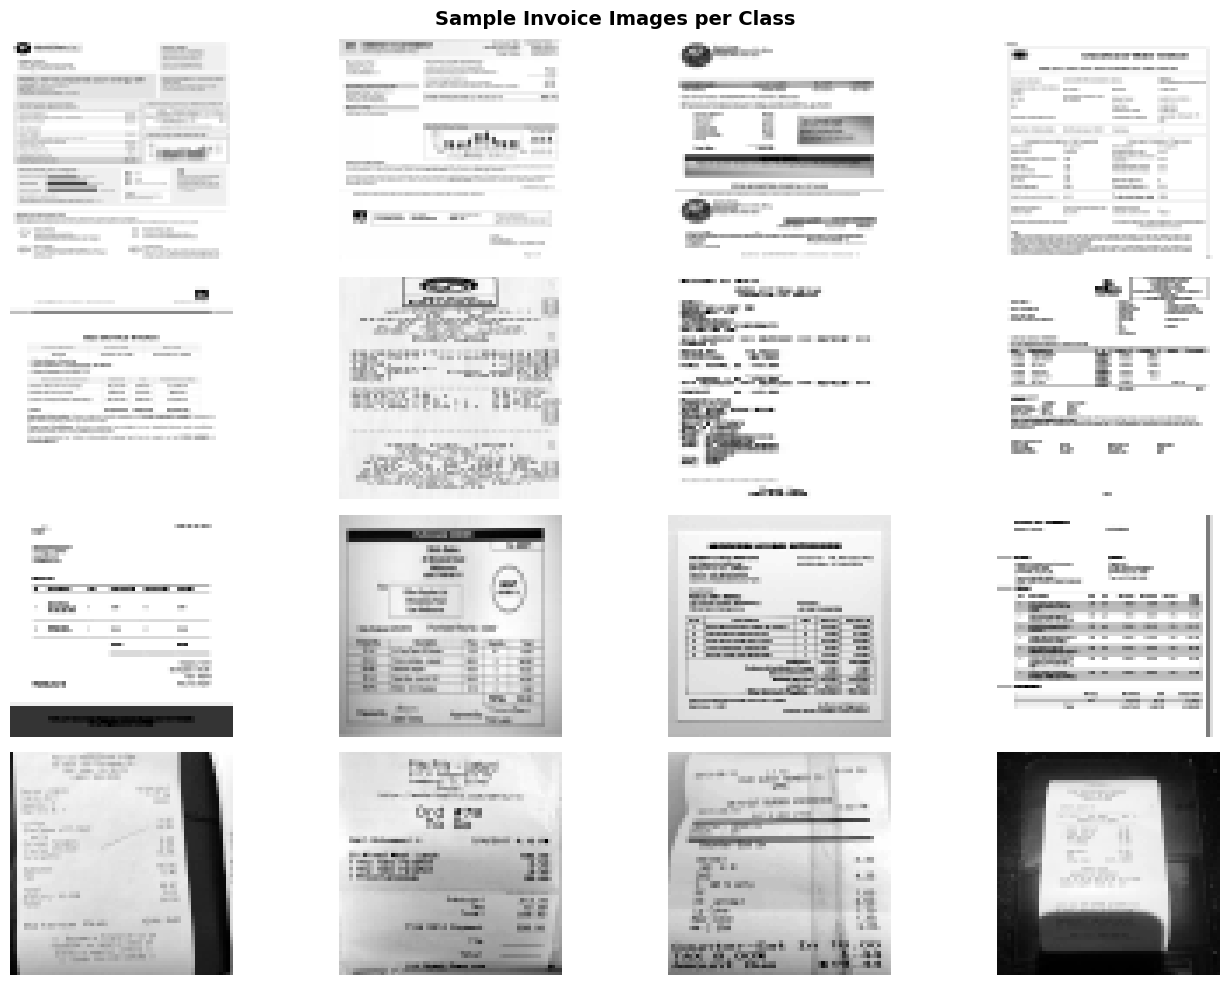

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\sample_images.png


In [5]:
def show_samples(X, y, classes, img_size, n=4):
    fig, axes = plt.subplots(len(classes), n, figsize=(14, 10))
    fig.suptitle('Sample Invoice Images per Class', fontsize=14, fontweight='bold')

    for cls_idx, cls_name in enumerate(classes):
        indices    = np.where(y == cls_idx)[0]
        sample_idx = random.sample(list(indices), min(n, len(indices)))

        for col, idx in enumerate(sample_idx):
            img = X[idx].reshape(img_size, img_size)
            axes[cls_idx][col].imshow(img, cmap='gray')
            axes[cls_idx][col].axis('off')
            if col == 0:
                axes[cls_idx][col].set_ylabel(cls_name, fontsize=10,
                                              fontweight='bold', rotation=0,
                                              labelpad=90)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'sample_images.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save_path}")


show_samples(X_raw, y_raw, CLASSES, IMG_SIZE)

In [6]:
def augment_image(flat_img, img_size):
    img   = flat_img.reshape(img_size, img_size)
    img_u8 = (img * 255).astype(np.uint8)

    # Slight rotation (±5°)
    angle  = random.uniform(-5, 5)
    center = (img_size // 2, img_size // 2)
    M      = cv2.getRotationMatrix2D(center, angle, 1.0)
    img_u8 = cv2.warpAffine(img_u8, M, (img_size, img_size),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_REPLICATE)

    # Contrast adjustment
    alpha  = random.uniform(0.8, 1.2)
    img_u8 = np.clip(img_u8.astype(np.float32) * alpha, 0, 255).astype(np.uint8)

    # Gaussian blur
    if random.random() > 0.5:
        ksize  = random.choice([3, 5])
        img_u8 = cv2.GaussianBlur(img_u8, (ksize, ksize), 0)

    return (img_u8.astype(np.float32) / 255.0).flatten()


def augment_dataset(X, y, augment_factor=2):
    X_aug, y_aug = [], []
    print(f"🔄 Augmenting dataset (factor={augment_factor})...")
    for i in tqdm(range(len(X))):
        for _ in range(augment_factor):
            X_aug.append(augment_image(X[i], IMG_SIZE))
            y_aug.append(y[i])

    X_combined = np.vstack([X, np.array(X_aug, dtype=np.float32)])
    y_combined = np.concatenate([y, np.array(y_aug, dtype=np.int32)])

    idx = np.random.permutation(len(X_combined))
    return X_combined[idx], y_combined[idx]


X_aug, y_aug = augment_dataset(X_raw, y_raw, augment_factor=2)
print(f"✅ After augmentation: X={X_aug.shape}, y={y_aug.shape}")

🔄 Augmenting dataset (factor=2)...


100%|██████████| 200/200 [00:00<00:00, 3389.88it/s]

✅ After augmentation: X=(600, 4096), y=(600,)


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_aug, y_aug, test_size=0.30, random_state=RANDOM_SEED, stratify=y_aug
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"✅ Split complete!")
print(f"   Train      : {X_train.shape[0]} samples")
print(f"   Validation : {X_val.shape[0]} samples")
print(f"   Test       : {X_test.shape[0]} samples")

✅ Split complete!
   Train      : 420 samples
   Validation : 90 samples
   Test       : 90 samples


C:\Users\User\AppData\Local\Temp\ipykernel_28028\541867263.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=20, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_28028\541867263.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=20, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_28028\541867263.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=20, ha='right')


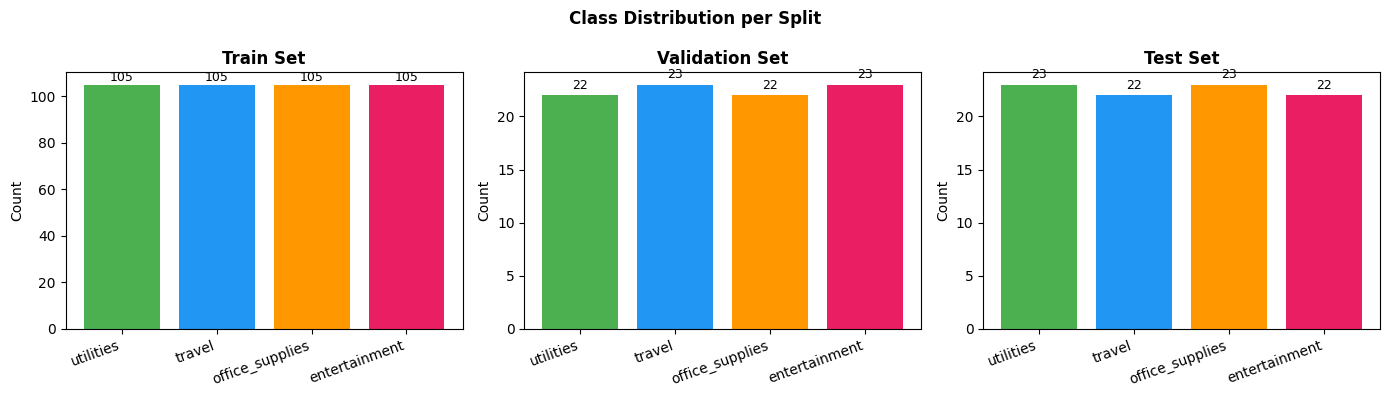

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4CAF50', '#2196F3', '#FF9800', '#E91E63']

for ax, (title, y_split) in zip(axes, [('Train', y_train),
                                         ('Validation', y_val),
                                         ('Test', y_test)]):
    counts = [np.sum(y_split == i) for i in range(len(CLASSES))]
    bars   = ax.bar(CLASSES, counts, color=colors)
    ax.set_title(f'{title} Set', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(CLASSES, rotation=20, ha='right')
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3, str(count),
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Class Distribution per Split', fontweight='bold')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'class_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

In [9]:
def extract_edge_density(flat_img, img_size=IMG_SIZE):
    img_u8 = (flat_img.reshape(img_size, img_size) * 255).astype(np.uint8)
    edges  = cv2.Canny(img_u8, 50, 150)
    return np.array([np.sum(edges > 0) / (img_size * img_size)], dtype=np.float32)

def extract_pixel_histogram(flat_img, n_bins=16):
    hist, _ = np.histogram(flat_img, bins=n_bins, range=(0, 1))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-8)
    return hist

def extract_hog_features(flat_img, img_size=IMG_SIZE):
    img = flat_img.reshape(img_size, img_size)
    return hog(img, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), feature_vector=True).astype(np.float32)

def extract_all_features(X):
    features = []
    for flat_img in tqdm(X, desc='Extracting features'):
        edge  = extract_edge_density(flat_img)
        hist  = extract_pixel_histogram(flat_img)
        hog_f = extract_hog_features(flat_img)
        features.append(np.concatenate([flat_img, edge, hist, hog_f]))
    return np.array(features, dtype=np.float32)


print("\n🔬 Extracting features for TRAIN...")
X_train_feat = extract_all_features(X_train)
print("🔬 Extracting features for VAL...")
X_val_feat   = extract_all_features(X_val)
print("🔬 Extracting features for TEST...")
X_test_feat  = extract_all_features(X_test)

INPUT_DIM = X_train_feat.shape[1]
print(f"\n✅ Feature extraction complete!")
print(f"   Input vector size per image: {INPUT_DIM}")


🔬 Extracting features for TRAIN...


Extracting features: 100%|██████████| 420/420 [00:00<00:00, 612.91it/s]


🔬 Extracting features for VAL...


Extracting features: 100%|██████████| 90/90 [00:00<00:00, 617.16it/s]


🔬 Extracting features for TEST...


Extracting features: 100%|██████████| 90/90 [00:00<00:00, 514.71it/s]


✅ Feature extraction complete!
   Input vector size per image: 5877


In [10]:
np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'),      X_train)
np.save(os.path.join(PROCESSED_DIR, 'X_val.npy'),        X_val)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'),       X_test)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'),      y_train)
np.save(os.path.join(PROCESSED_DIR, 'y_val.npy'),        y_val)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'),       y_test)
np.save(os.path.join(PROCESSED_DIR, 'X_train_feat.npy'), X_train_feat)
np.save(os.path.join(PROCESSED_DIR, 'X_val_feat.npy'),   X_val_feat)
np.save(os.path.join(PROCESSED_DIR, 'X_test_feat.npy'),  X_test_feat)

print("✅ All processed data saved!")

✅ All processed data saved!


In [11]:
def build_mlp(input_dim, num_classes=4,
              hidden_units=[512, 256, 128],
              dropout_rates=[0.3, 0.3, 0.2],
              learning_rate=1e-3):

    model = keras.Sequential(name='InvoiceGuard_MLP')
    model.add(layers.Input(shape=(input_dim,)))

    for units, dropout in zip(hidden_units, dropout_rates):
        model.add(layers.Dense(units, use_bias=False))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_mlp(INPUT_DIM)
model.summary()

Model: "InvoiceGuard_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     3,009,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,176,964 (12.12 MB)

 Trainable params: 3,175,172 (12.11 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [12]:
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'best_model.keras'),
    monitor='val_accuracy', save_best_only=True, verbose=1
)

print("\n🚀 Training started...\n")
history = model.fit(
    X_train_feat, y_train,
    validation_data=(X_val_feat, y_val),
    epochs=80,
    batch_size=32,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)
print("\n✅ Training complete!")


🚀 Training started...

Epoch 1/80
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3666 - loss: 1.4131
Epoch 1: val_accuracy improved from None to 0.27778, saving model to d:\Lecture Notes\projects\InvoiceGuard\models\best_model.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.4524 - loss: 1.2091 - val_accuracy: 0.2778 - val_loss: 5.0490 - learning_rate: 0.0010
Epoch 2/80
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6417 - loss: 0.8837
Epoch 2: val_accuracy did not improve from 0.27778
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6452 - loss: 0.8638 - val_accuracy: 0.2667 - val_loss: 8.7456 - learning_rate: 0.0010
Epoch 3/80
13/14 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7179 - loss: 0.6946
Epoch 3: val_accuracy did not improve from 0.27778
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7190 - loss: 0.6808 - val_accuracy: 0.2778 - val_loss: 4.8838 - learning_rate: 0.0010
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.79

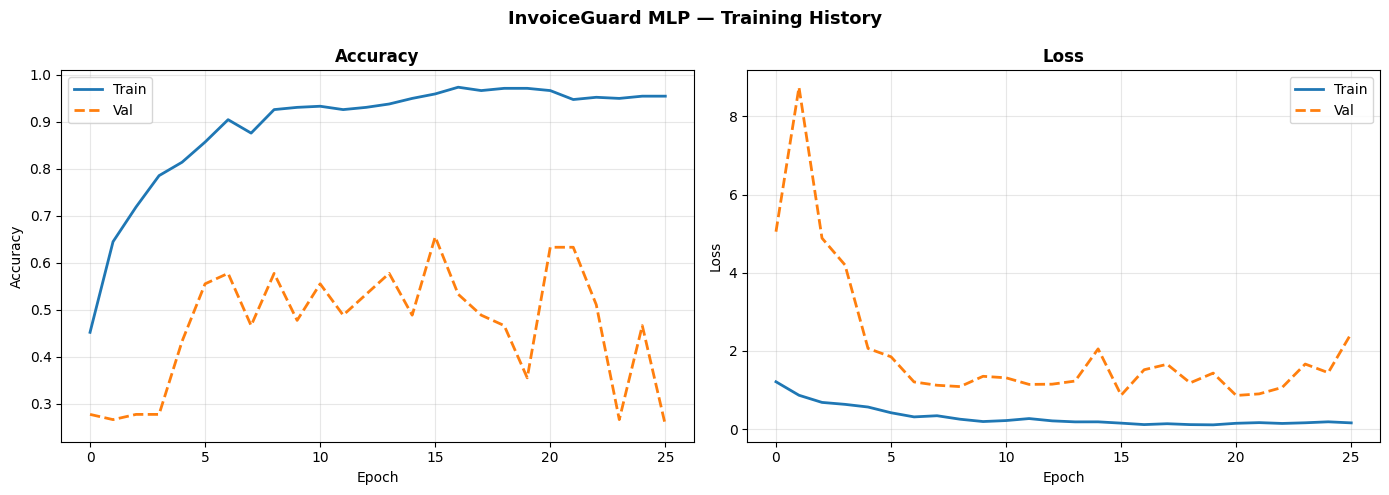

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\training_history.png


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('InvoiceGuard MLP — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'training_history.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

In [14]:
CLASSES_DISPLAY = ['Utilities', 'Travel', 'Office Supplies', 'Entertainment']

best_model = keras.models.load_model(os.path.join(MODEL_DIR, 'best_model.keras'))

y_proba      = best_model.predict(X_test_feat, verbose=0)
y_pred       = np.argmax(y_proba, axis=1)
y_confidence = np.max(y_proba, axis=1)

overall_acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"  Overall Test Accuracy : {overall_acc*100:.2f}%")
print(f"  Mean Confidence       : {y_confidence.mean()*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(y_test, y_pred, target_names=CLASSES_DISPLAY, digits=4))


  Overall Test Accuracy : 65.56%
  Mean Confidence       : 66.96%

                 precision    recall  f1-score   support

      Utilities     0.8000    0.8696    0.8333        23
         Travel     1.0000    0.2273    0.3704        22
Office Supplies     0.5000    0.5217    0.5106        23
  Entertainment     0.6111    1.0000    0.7586        22

       accuracy                         0.6556        90
      macro avg     0.7278    0.6546    0.6182        90
   weighted avg     0.7260    0.6556    0.6194        90



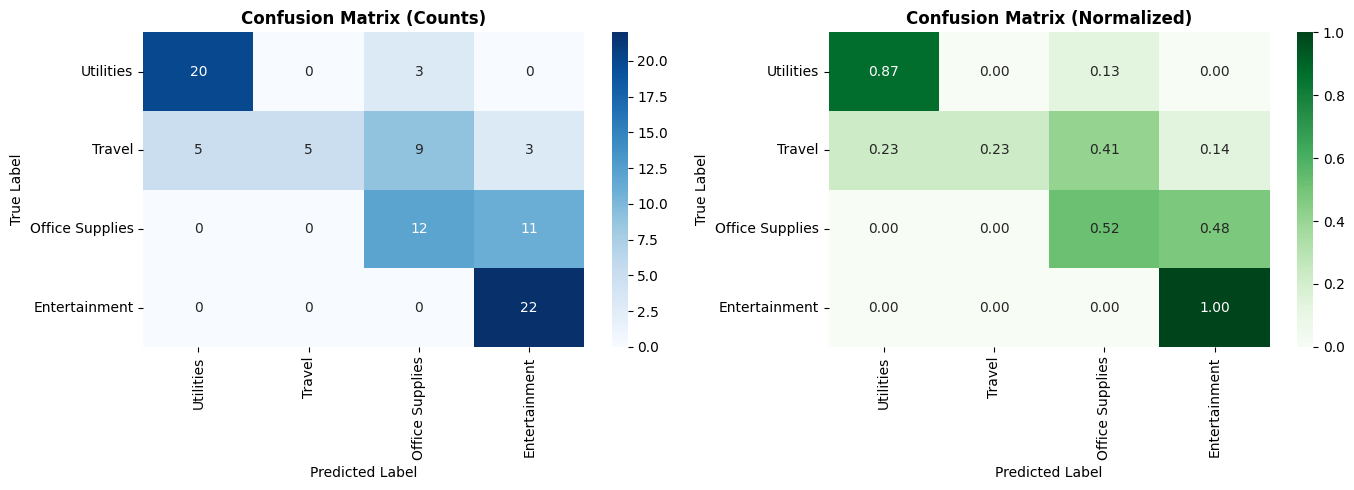

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\confusion_matrix.png


In [15]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES_DISPLAY,
            yticklabels=CLASSES_DISPLAY, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASSES_DISPLAY,
            yticklabels=CLASSES_DISPLAY, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

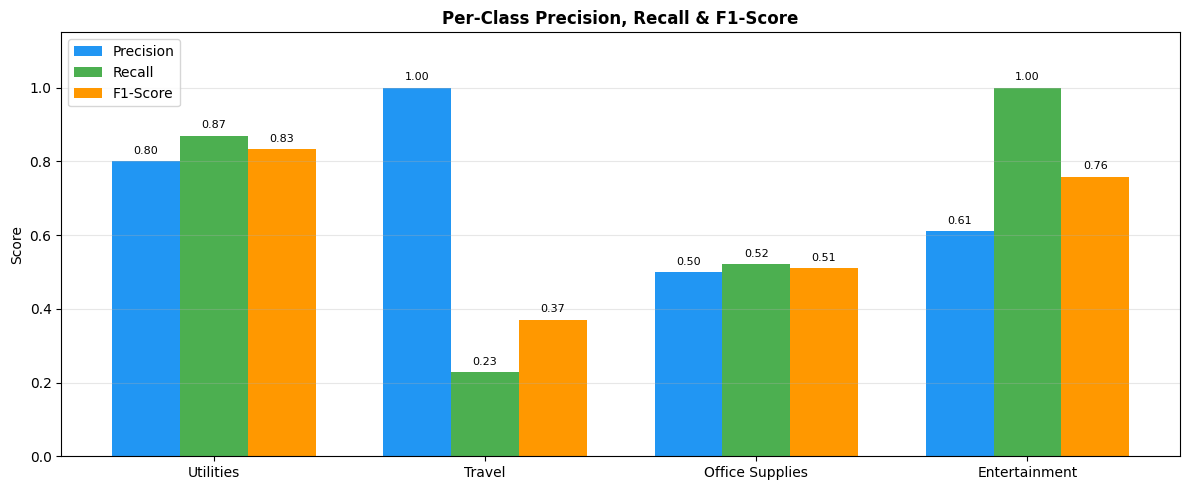

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\per_class_metrics.png


In [16]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average=None
)

x     = np.arange(len(CLASSES_DISPLAY))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width, precision, width, label='Precision', color='#2196F3')
ax.bar(x,         recall,    width, label='Recall',    color='#4CAF50')
ax.bar(x + width, f1,        width, label='F1-Score',  color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES_DISPLAY)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall & F1-Score', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(i - width, p + 0.02, f'{p:.2f}', ha='center', fontsize=8)
    ax.text(i,         r + 0.02, f'{r:.2f}', ha='center', fontsize=8)
    ax.text(i + width, f + 0.02, f'{f:.2f}', ha='center', fontsize=8)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'per_class_metrics.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")

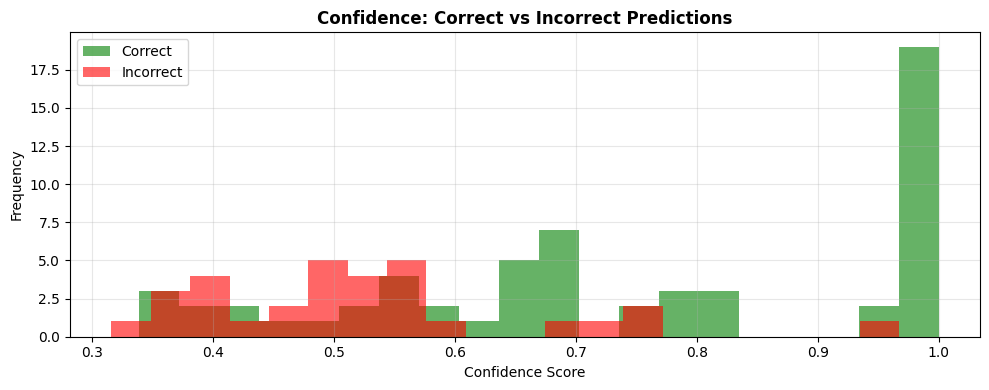

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\confidence_distribution.png


In [17]:
correct_conf   = y_confidence[y_pred == y_test]
incorrect_conf = y_confidence[y_pred != y_test]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_conf,   bins=20, alpha=0.6, label='Correct',   color='green')
ax.hist(incorrect_conf, bins=20, alpha=0.6, label='Incorrect', color='red')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Frequency')
ax.set_title('Confidence: Correct vs Incorrect Predictions', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'confidence_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {save_path}")


❌ Misclassified : 31 / 90
   Error rate    : 34.44%


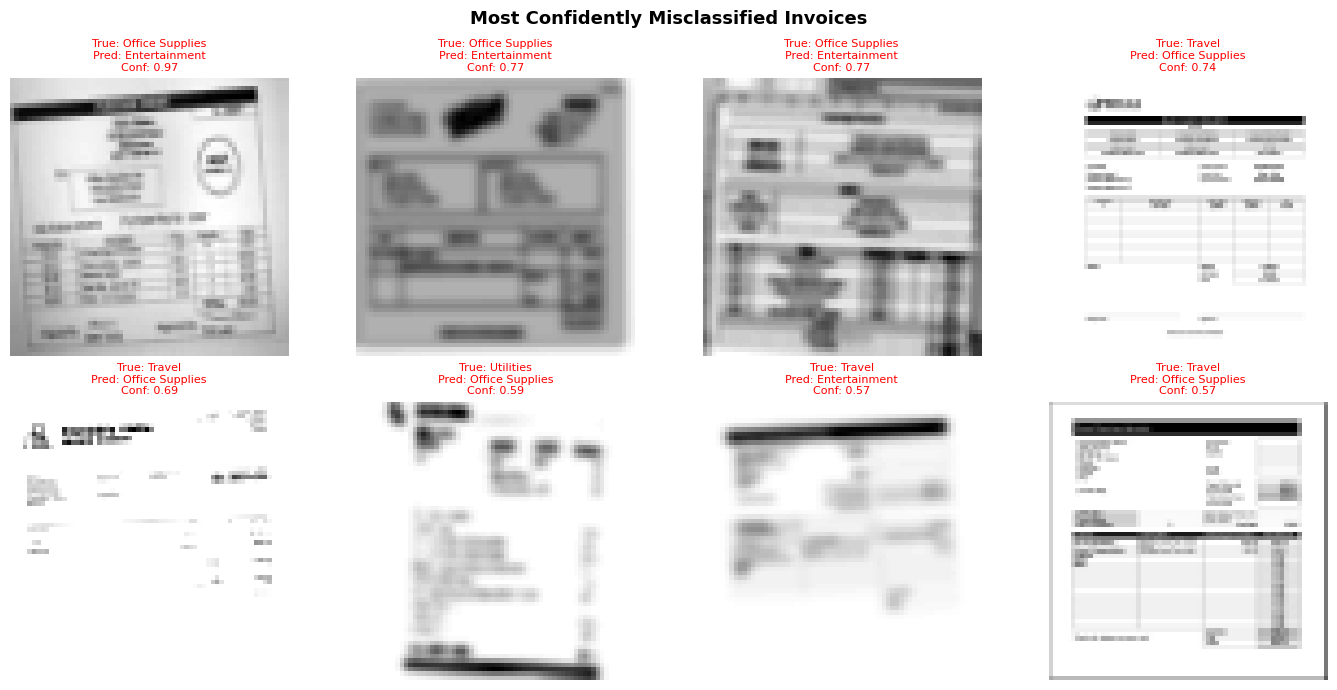

✅ Saved → d:\Lecture Notes\projects\InvoiceGuard\outputs\misclassified_samples.png


In [18]:
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"\n❌ Misclassified : {len(misclassified_idx)} / {len(y_test)}")
print(f"   Error rate    : {len(misclassified_idx)/len(y_test)*100:.2f}%")

if len(misclassified_idx) > 0:
    wrong_conf  = y_confidence[misclassified_idx]
    sorted_idx  = misclassified_idx[np.argsort(-wrong_conf)]
    n_show      = min(8, len(sorted_idx))

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle('Most Confidently Misclassified Invoices',
                 fontweight='bold', fontsize=13)

    for i, ax in enumerate(axes.flatten()):
        if i >= n_show:
            ax.axis('off')
            continue
        idx       = sorted_idx[i]
        img       = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)
        true_cls  = CLASSES_DISPLAY[y_test[idx]]
        pred_cls  = CLASSES_DISPLAY[y_pred[idx]]
        conf      = y_confidence[idx]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls}\nConf: {conf:.2f}',
                     fontsize=8, color='red')
        ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'misclassified_samples.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save_path}")

In [19]:
print("\n" + "="*50)
print("  🎉 InvoiceGuard Pipeline Complete!")
print("="*50)
print(f"\n  Model saved  → {os.path.join(MODEL_DIR, 'best_model.keras')}")
print(f"  All plots    → {OUTPUT_DIR}")
print(f"\n  To launch the web UI, run:")
print(f"  streamlit run app/app.py")
print("="*50)


  🎉 InvoiceGuard Pipeline Complete!

  Model saved  → d:\Lecture Notes\projects\InvoiceGuard\models\best_model.keras
  All plots    → d:\Lecture Notes\projects\InvoiceGuard\outputs

  To launch the web UI, run:
  streamlit run app/app.py
